<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 2: Variables aleatorias y muestreo
        </td>
    </tr>
    <tr>
 

</table>

##  Ejercicio 1

Obtener con python las muestras de las siguientes distribuciones:

a) 10 valores de la uniforme $[0, 1)$

b) 5 días de la semana, con repetición.

c) 8 valores de tirar 2 dados.

## Solución

a) Se emplea la función random.rand de la librería numpy para simular una distribución
uniforme

In [2]:
import numpy as np

#Definimos una semilla
np.random.seed(2026)
muestra_uniforme = np.random.rand(10)
print("La muestra uniforme es ", muestra_uniforme)

La muestra uniforme es  [0.21934563 0.41301174 0.97663548 0.08889902 0.47928986 0.98755049
 0.19814109 0.91171518 0.55825011 0.78322947]


b) Se emplea la función random.randint de la librería numpy para simular números enteros

In [3]:
np.random.seed(2025) #Obtener los mismos días

dias_semana = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"] #7 días
muestra_semana = np.random.randint(7,size=5)

print(dias_semana[muestra_semana[0]], dias_semana[muestra_semana[1]], 
      dias_semana[muestra_semana[2]], dias_semana[muestra_semana[3]], 
      dias_semana[muestra_semana[4]])

Domingo Domingo Miércoles Domingo Viernes


In [4]:
muestra_semana

array([6, 6, 2, 6, 4], dtype=int32)

c) Se emplea la función random.randint de la librería numpy para simular números enteros. Hay que simular cada dado por separado para tener en cuenta correctamente
las probabilidades de la suma de tiradas de los mismos.

In [5]:
np.random.seed(2026)

dado_1 = np.random.randint(1,7,size=8)
dado_2 = np.random.randint(1,7,size=8)

suma_dados = dado_1+dado_2
print("Los valores del dado 1 son ", dado_1)
print("Los valores del dado 2 son ", dado_2)
print("La suma de los dados es ", suma_dados)

Los valores del dado 1 son  [2 3 1 6 6 6 5 5]
Los valores del dado 2 son  [4 6 5 5 3 6 4 1]
La suma de los dados es  [ 6  9  6 11  9 12  9  6]


## Ejercicio 2

La altura de una población se distribuye como una normal de media 170 y desviación típica 5. Se pide:

a) Obtener las siguientes muestras de la población y representar las distribuciones obtenidas gráficamente:

 - 10 valores de la normal ($\mu= 170$, $\sigma = 5$)
 - 100 valores de la normal ($\mu= 170$, $\sigma = 5$)
 - 10000 valores de la normal ($\mu= 170$, $\sigma = 5$)

b) Obtener el valor teórico de la distribución normal ($\mu = 170$, $\sigma = 5$)

c)  Calcular la probabilidad de que una persona mida menos de 160 cm o más de 195 
cm.

## Solución

a) Se cargan las librerías que se van a necesitar para la resolución del problema

In [6]:
#Cargar librerias

import pandas as pd
import numpy as np
from pandas.core.common import flatten
from plotnine import ggplot, aes, geom_density, ylab, xlab, theme_bw, theme, geom_line, ylim, xlim, geom_vline
from array import *
import scipy.stats as stats
import math
import matplotlib.pyplot as plt

In [7]:
#Definir semilla para que los resultados sean los mismos
np.random.seed(seed = 2026)

#Definir las muestras
a1 = np.random.normal(170,5,10) #Muestra 1
a2 = np.random.normal(170,5,100) #Muestra 2
a3 = np.random.normal(170,5,10000) #Muestra 3

#Crear dataframe
#Lista de los valores muestreo
l_a1 = a1.tolist()
l_a2 = a2.tolist()
l_a3 = a3.tolist()

l_comb = l_a1 + l_a2 + l_a3

#Lista de la muestra a la que corresponde cada valor
clase = [["n = 10"] * 10, ["n = 100"] * 100, ["n = 10000"] * 10000] 
# Una sola lista
flattened_clase = list(flatten(clase))

In [8]:
# crear dataframe
d = {"Altura":l_comb, "Muestra":flattened_clase}
df = pd.DataFrame(d)

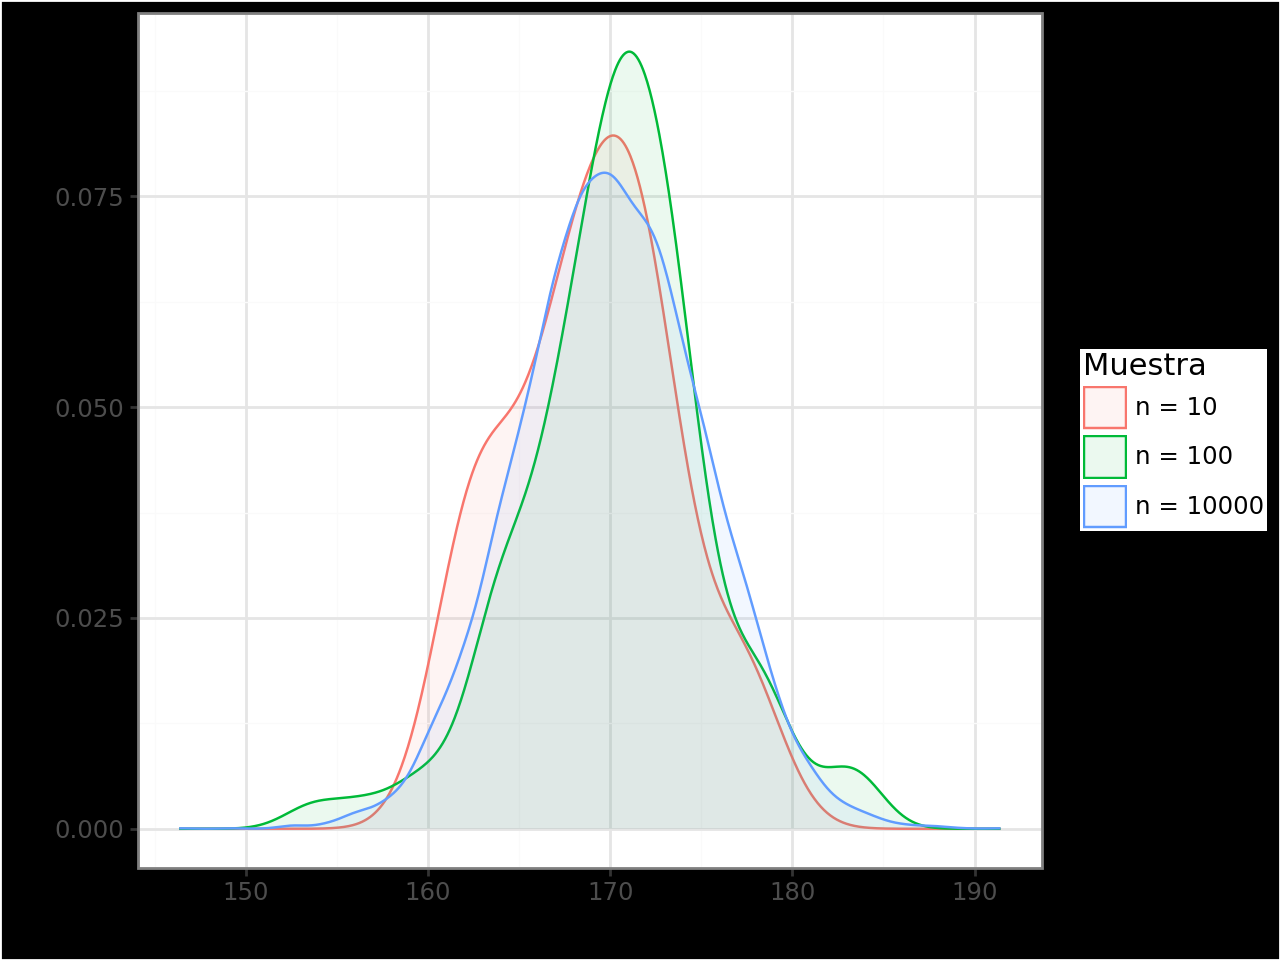

In [9]:
(
ggplot(df, aes(x = "Altura", color = "Muestra",
fill = "Muestra")) +
geom_density(alpha = 0.08) +
ylab("Densidad de probabilidad") +
xlab("Altura (cm)") +
theme_bw() +
theme(legend_position = "right")
)

b) Se representa la función de densidad real de la normal ($\mu$ = 170, $\sigma$= 5). Para ello
se utiliza la librería scipy, que mediante la función stats.norm.pdf permite obtener
la función de densidad de una distribución normal. Se ratifica que se parece mucho
a la función de densidad obtenida en el apartado a) con n = 10000.

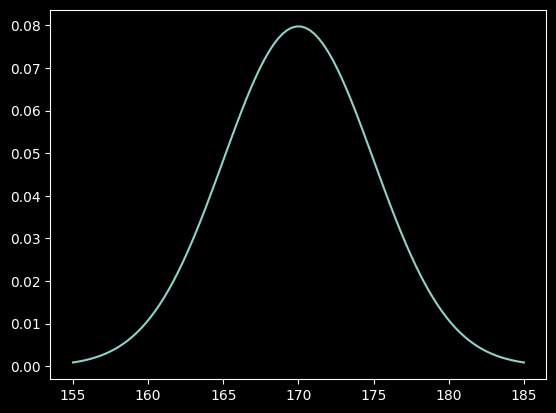

In [10]:
mu = 170
sigma = 5

x = np.linspace(mu-3*sigma,mu+3*sigma,100)
y = stats.norm.pdf(x,mu,sigma)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(x,y)
plt.show()

c) La probabilidad será la suma de la probabilidad de que una persona mida menos de 160 cm + la probabilidad de que mida más de 195 cm. Además, la probabilidad
de que mida más de 195 cm se puede obtener como 1 - probabilidad de que mida menos de 195 cm. Por lo tanto:

$$p = p_1+p_2=P(X<160)+(1-P(X<165))$$

En python, $p_1$ y $p_2$ se pueden calcular mediante la función stats.norm.cdf de la librería
scipy.

Se observa que la probabilidad es muy pequeña. A continuación, se presenta la función
de distribución de probabilidad.

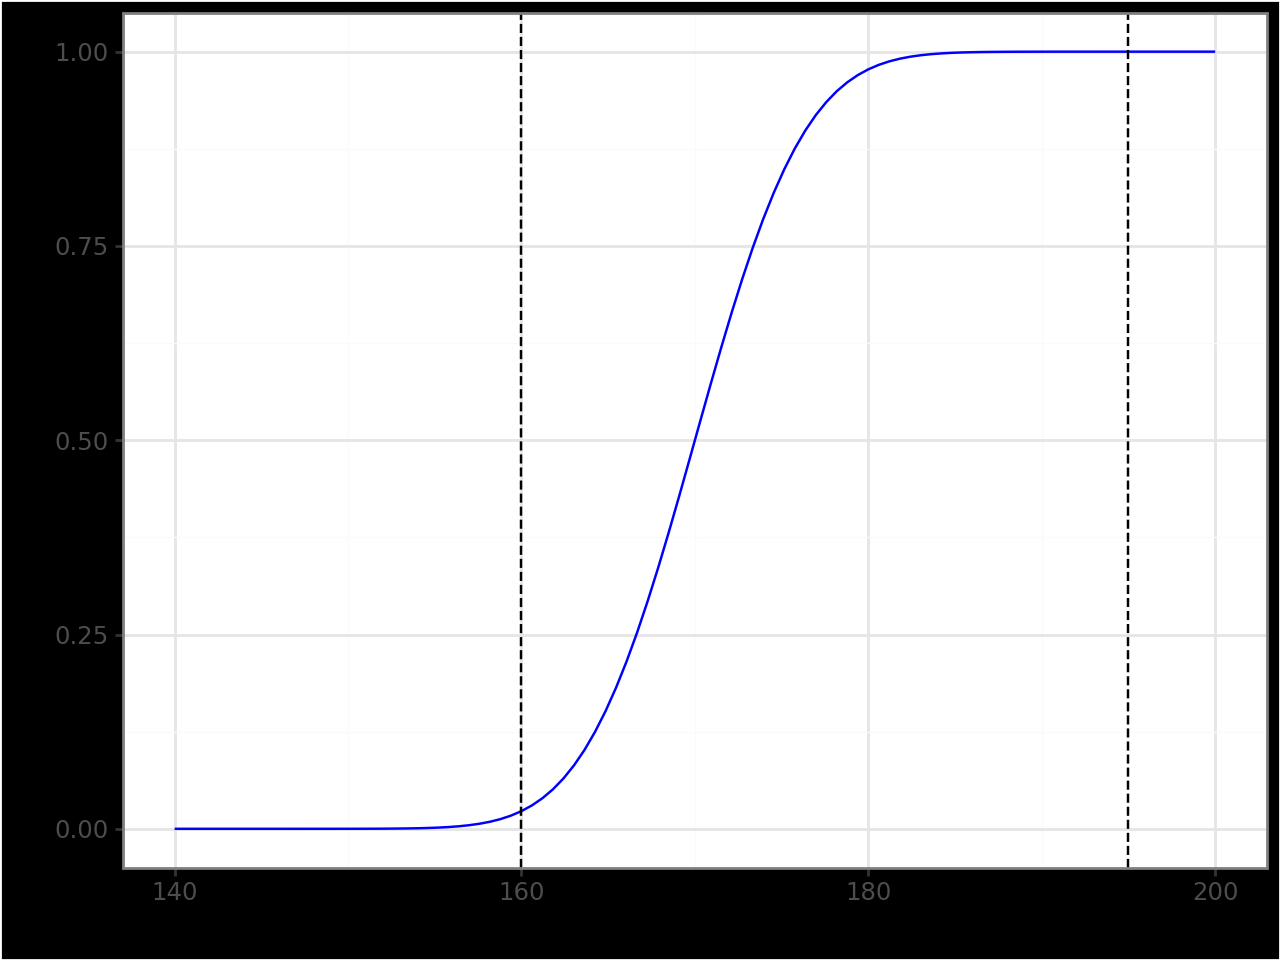

In [11]:
# Representar la funcion de distribucion de probabilidad
x = np.linspace(mu - 6*sigma, mu + 6*sigma, 100)
y = stats.norm.cdf(x, mu, sigma)
(
ggplot(aes(x = x, y = y)) +
geom_line(color = "blue") +
geom_vline(xintercept = [160,195], linetype = "dashed") +
ylim(0, 1) +
ylab("Probabilidad acumulada") +
xlab("Altura (cm)") +
theme_bw() +
theme(legend_position = "right")
)


## Ejercicio 3

Latveria y Symkaria son dos poblaciones vecinas. Los hombres y mujeres de Latveria
miden de media 175 cm y 169 cm respectivamente y tienen para ámbas distribuciones
una desviación típica de 6 cm. En Symkaria, en cambio, las mujeres miden de media
173 cm y los hombres 171. La desviación típica en la altura de las mujeres de Symkaria
es de 7 cm y en la de los hombres de 3

a) Con estos datos, conformar un dataframe que contenga las medidas de 2000 hombres
y de 2000 mujeres de cada población. Calcula la media y la desviación típica de la
ponblació

b) Realizar un muestreo estratificado con 4 estratos y n = 100/estrato. Calcular la media
y desviación típica de cada estrato.

c) Realiza un muestreo por conglomerados con 2 conglomerados y n = 200/conglomerado. Calcula la media y desviación típica de cada conglomerado.n. cm.

## Solución

a) Mediante la función random.normal de la librería numpy se obtienen los valores de
la normal para los distintos grupos

In [12]:
# Definir semilla para que los resultados sean los mismos

np.random.seed(seed = 2026)
latveria_h = np.random.normal(175, 6, 2000)
symkaria_h = np.random.normal(171, 3, 2000)

De manera similar a lo realizado en el ejercicio 2 se conforma el data frame.

In [13]:
#Conformar data frame

#Lista de los valores muestreo
l_lh = latveria_h.tolist()
l_lm = latveria_m.tolist()
l_sh = symkaria_h.tolist()
l_sm = symkaria_m.tolist()
l_comb = l_lh + l_lm + l_sh + l_sm

# Lista del sexo a la que corresponde cada valor
sexo = [["Hombre"] * 2000, ["Mujer"] * 2000] * 2

#Una sola lista
flattened_sexo = list(flatten(sexo))
# len(flattened_clase)
# lista del pais a la que corresponde cada valor
pais = [["Latveria"] * 4000, ["Symkaria"] * 4000]
# Una sola lista
flattened_pais = list(flatten(pais))


#Crear dataframe
d = {"Altura":l_comb,"Sexo":flattened_sexo,"Pais":flattened_pais}
df = pd.DataFrame(d)

NameError: name 'latveria_m' is not defined

In [ ]:
#Vista previa del data frame
df

Se obtienen los resultados de la media y desviación típica poblacional empleando las
funciones mean y std de la librería numpy.

In [ ]:
media = np.mean(df["Altura"])
desv = np.std(df["Altura"])
print("La media es ", round(media,4), " y la desv. tip. es ",round(desv,4))

b) Para seleccionar los estratos debemos seleccionar las 4 combinaciones distintas de sexo y país. Posteriormente, se realiza una estracción aleatoria de 100 individuos
por estrato con la función sample sobre el dataframe. Por último, se calcula la media y la desviación estándar para cada estrato

In [ ]:
np.random.seed(seed = 2026)

# Generar filtros
e_h = df["Sexo"] == "Hombre"
e_m = df["Sexo"] == "Mujer"
e_L = df["Pais"] == "Latveria"
e_S = df["Pais"] == "Symkaria"

# Generar estratos
estrato1 = df[e_h & e_L] # Hombres Latveria
estrato2 = df[e_m & e_L] # Mujeres Latveria
estrato3 = df[e_h & e_S] # Hombres Symkaria
estrato4 = df[e_m & e_S] # Mujeres Symkaria

#Muestrear en cada estrato
sample_1 = estrato1.sample(frac = 0.05)
sample_2 = estrato2.sample(frac = 0.05)
sample_3 = estrato3.sample(frac = 0.05)
sample_4 = estrato4.sample(frac = 0.05)


#Calcular media y desv. tip.
print("La media del estrato 1 es ", round(np.mean(sample_1["Altura"]), 4), " y la desv. tip. es ", 
      round(np.std(sample_1["Altura"]), 4))


In [14]:
print("La media del estrato 2 es ", round(np.mean(sample_2["Altura"]), 4), " y la desv. tip. es ", 
      round(np.std(sample_2["Altura"]), 4))

NameError: name 'sample_2' is not defined

In [ ]:
print("La media del estrato 3 es ", round(np.mean(sample_3["Altura"]), 4), " y la desv. tip. es ", 
      round(np.std(sample_3["Altura"]), 4))

In [ ]:
print("La media del estrato 4 es ", round(np.mean(sample_4["Altura"]), 4), " y la desv. tip. es ", 
      round(np.std(sample_4["Altura"]), 4))

c) Aprovechando los estratos definidos del apartado anterior se conforman los conglomerados. En concreto, cada conglomerado estará formado por 50 observaciones de
cada uno de los estratos.

In [1]:
np.random.seed(seed = 2026)
#Muestrear en cada estrato para el conglomerado 1
sample_1 = estrato1.sample(frac = 0.025)
sample_2 = estrato2.sample(frac = 0.025)
sample_3 = estrato3.sample(frac = 0.025)
sample_4 = estrato4.sample(frac = 0.025)


#Conformar conglomerado 1
con_1 = pd.concat([sample_1,sample_2,sample_3,sample_4])

#Muestrear en cada estrato para el conglomerado 2
sample_1 = estrato1.sample(frac = 0.025)
sample_2 = estrato2.sample(frac = 0.025)
sample_3 = estrato3.sample(frac = 0.025)
sample_4 = estrato4.sample(frac = 0.025)

#Conformar conglomerado 2
con_2 = pd.concat([sample_1,sample_2,sample_3,sample_4])


#Calcular media y desv. tip.
print("La media del conglomerado 1 es ",round(np.mean(con_1["Altura"]), 4),
" y la desv. tip. es ", round(np.std(con_1["Altura"]), 4))

print("La media del conglomerado 2 es ",round(np.mean(con_2["Altura"]), 4),
" y la desv. tip. es ", round(np.std(con_2["Altura"]), 4))

NameError: name 'np' is not defined